# Step 3: Model Selection & Training
**FreshGuard ML Pipeline**

**ML Objective:** Predict whether a product batch will **expire before being fully sold** (`expire_before_sold`) using engineered inventory and demand features.

We train **two models** to compare learning behavior and keep the stronger one for deployment.


## 3.1 Train / Test Split (80% / 20%)

## 3.2 Model 1: Logistic Regression (Baseline)

- Outputs a **probability score** (0-1), not a fixed decision.
- Easy to interpret.
- Strong baseline for comparison.

## 3.3 Model 2: Random Forest Classifier (Primary)

- Ensemble of decision trees.
- Learns **non-linear** relationships and feature interactions.
- Cannot be replicated by simple rules.

## 3.4 Hyperparameter Tuning (RandomizedSearchCV)

> *'Hyperparameter tuning allows the model to learn optimal decision boundaries instead of fixed thresholds. Rules do not have decision boundaries — ML does.'*

Instead of testing every possible combination, we sample a smaller set of strong candidate settings to reduce runtime and memory usage.

CPU cores detected: 16
Random Forest worker threads: 4
SearchCV workers: 1 (Windows-safe setting)
Loaded feature dataset: (100000, 23)
Training set: (80000, 22)
Test set: (20000, 22)
Train target distribution:
expire_before_sold
1    0.565
0    0.435
Name: proportion, dtype: float64
Test target distribution:
expire_before_sold
1    0.565
0    0.435
Name: proportion, dtype: float64
Logistic Regression trained.
Train accuracy: 0.7727
Test accuracy:  0.7773
Logistic Regression - 5-fold CV ROC-AUC: 0.8757 (+/- 0.0027)
Random Forest trained.
Train accuracy: 1.0000
Test accuracy:  0.9441
Random Forest - 5-fold CV ROC-AUC: 0.9889 (+/- 0.0006)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Sampled parameter settings: 12
Best params: {'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': None}
Best CV ROC-AUC: 0.9884
Best model train accuracy: 1.0000
Best model test accuracy:  0.9427
=== Top 10 Most Important Features ===
expiry_press

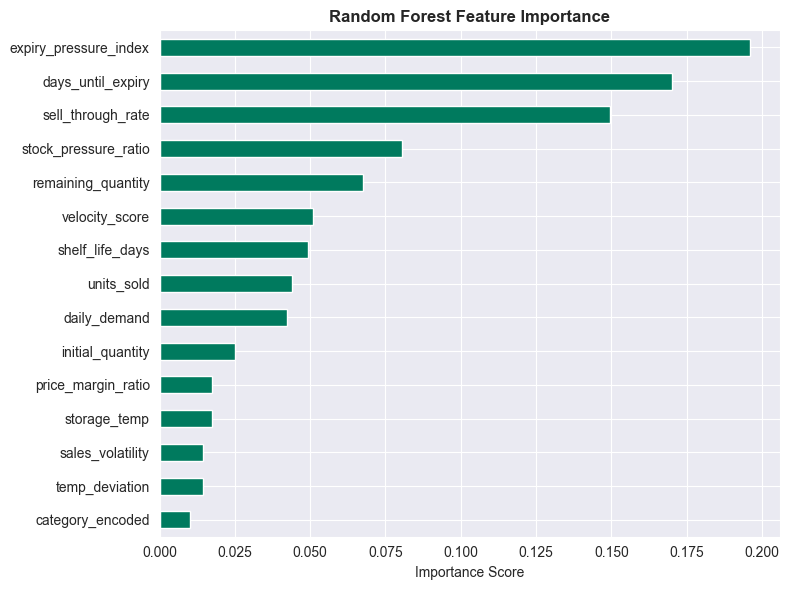

Models and data splits saved to outputs/
  logistic_regression_model.pkl
  random_forest_model.pkl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os, warnings, joblib
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

with open('outputs/feature_list.json') as f:
    meta = json.load(f)
FEATURES = meta['features']
TARGET = meta['target']

CPU_COUNT = os.cpu_count() or 4
RF_N_JOBS = max(1, min(4, CPU_COUNT - 1))
GRID_SEARCH_JOBS = 1
print(f'CPU cores detected: {CPU_COUNT}')
print(f'Random Forest worker threads: {RF_N_JOBS}')
print(f'SearchCV workers: {GRID_SEARCH_JOBS} (Windows-safe setting)')

df = pd.read_csv('outputs/feature_dataset.csv')
print(f'Loaded feature dataset: {df.shape}')

# Downcast feature dtypes to reduce memory pressure during CV and grid search.
X = df[FEATURES].copy()
float_cols = X.select_dtypes(include=['float64', 'float32']).columns
int_cols = X.select_dtypes(include=['int64', 'int32', 'int16', 'int8', 'uint8']).columns
X[float_cols] = X[float_cols].astype(np.float32)
X[int_cols] = X[int_cols].astype(np.int32)
y = df[TARGET].astype(np.int8)
del df

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print('Train target distribution:')
print(y_train.value_counts(normalize=True).round(3))
print('Test target distribution:')
print(y_test.value_counts(normalize=True).round(3))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
print('Logistic Regression trained.')
print(f'Train accuracy: {lr_pipeline.score(X_train, y_train):.4f}')
print(f'Test accuracy:  {lr_pipeline.score(X_test, y_test):.4f}')

lr_cv = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='roc_auc')
print(f'Logistic Regression - 5-fold CV ROC-AUC: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})')

# Random Forest
rf_pipeline = Pipeline([
    ('clf', RandomForestClassifier(
        random_state=42,
        n_jobs=RF_N_JOBS,
        class_weight='balanced_subsample'
    ))
])

rf_pipeline.fit(X_train, y_train)
print('Random Forest trained.')
print(f'Train accuracy: {rf_pipeline.score(X_train, y_train):.4f}')
print(f'Test accuracy:  {rf_pipeline.score(X_test, y_test):.4f}')

rf_cv = cross_val_score(rf_pipeline, X, y, cv=cv, scoring='roc_auc')
print(f'Random Forest - 5-fold CV ROC-AUC: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})')

# Hyperparameter tuning
param_grid = {
    'clf__n_estimators': [200, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2]
}

grid_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=12,
    cv=cv,
    scoring='roc_auc',
    n_jobs=GRID_SEARCH_JOBS,
    pre_dispatch=GRID_SEARCH_JOBS,
    random_state=42,
    error_score='raise',
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f'Sampled parameter settings: {grid_search.n_iter}')
print(f'Best params: {grid_search.best_params_}')
print(f'Best CV ROC-AUC: {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_
print(f'Best model train accuracy: {best_model.score(X_train, y_train):.4f}')
print(f'Best model test accuracy:  {best_model.score(X_test, y_test):.4f}')

# Feature importance
rf_clf = best_model.named_steps['clf']
importances = rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=False)

print('=== Top 10 Most Important Features ===')
print(feat_imp.head(10).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.head(15).sort_values().plot(kind='barh', ax=ax, color='#007A5E')
ax.set_title('Random Forest Feature Importance', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Save models and splits
joblib.dump(lr_pipeline, 'outputs/logistic_regression_model.pkl')
joblib.dump(best_model, 'outputs/random_forest_model.pkl')

X_test.to_csv('outputs/X_test.csv', index=False)
y_test.to_csv('outputs/y_test.csv', index=False)
X_train.to_csv('outputs/X_train.csv', index=False)
y_train.to_csv('outputs/y_train.csv', index=False)

print('Models and data splits saved to outputs/')
print('  logistic_regression_model.pkl')
print('  random_forest_model.pkl')


## 3.5 Step 3 Slide Visuals

The next cell creates four presentation-ready outputs for Step 3 only:
- Cross-Validation Accuracy Comparison of Models
- Logistic Regression Feature Coefficients
- Random Forest Feature Importance
- Random Forest Hyperparameter Tuning Results

=== Cross-Validation Accuracy Comparison ===
                Model  Mean_CV_Accuracy  Std_CV_Accuracy
  Logistic Regression            0.7732           0.0029
Random Forest (Tuned)            0.9432           0.0018


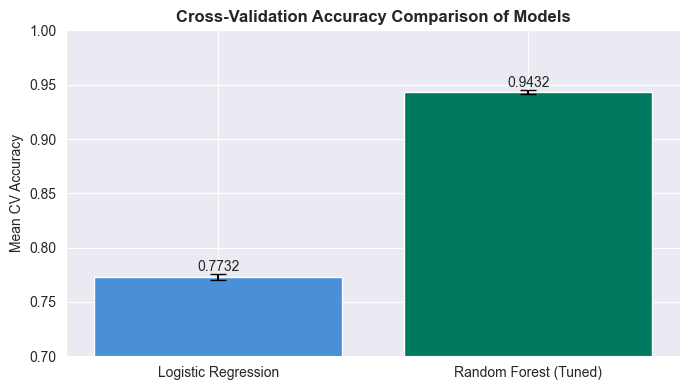

=== Top Logistic Regression Coefficients ===
expiry_pressure_index    2.3915
sell_through_rate       -1.0666
days_until_expiry       -1.0129
shelf_life_days          0.8015
velocity_score           0.4407
daily_demand             0.3939
is_weekend              -0.2997
category_encoded         0.1620
initial_quantity        -0.1326
spoilage_sensitivity    -0.1183


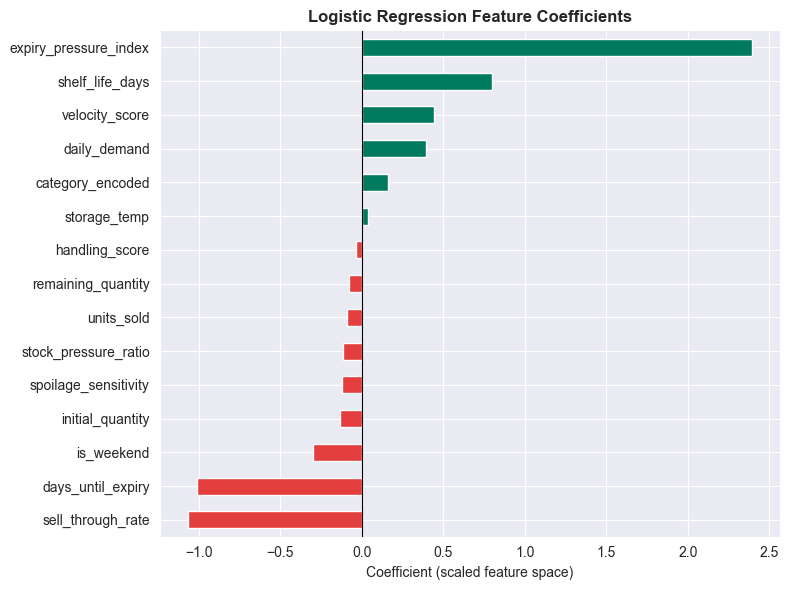

=== Top Random Forest Feature Importance Values ===
expiry_pressure_index    0.1962
days_until_expiry        0.1701
sell_through_rate        0.1496
stock_pressure_ratio     0.0803
remaining_quantity       0.0677
velocity_score           0.0509
shelf_life_days          0.0493
units_sold               0.0439
daily_demand             0.0424
initial_quantity         0.0250


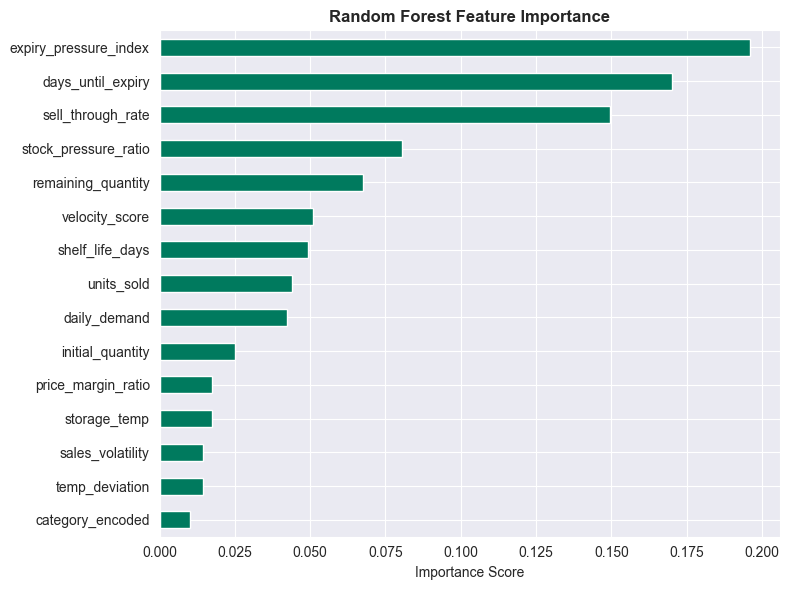

=== Best Random Forest Tuning Results ===
                        Configuration  Mean_CV_ROC_AUC  Std_CV_ROC_AUC  Rank  n_estimators max_depth  min_samples_split  min_samples_leaf
n=300 | depth=None | split=2 | leaf=1           0.9884          0.0003     1           300      None                  2                 1
n=200 | depth=None | split=2 | leaf=1           0.9884          0.0004     2           200      None                  2                 1
n=200 | depth=None | split=5 | leaf=1           0.9882          0.0002     3           200      None                  5                 1
n=300 | depth=None | split=2 | leaf=2           0.9881          0.0002     4           300      None                  2                 2
  n=200 | depth=20 | split=2 | leaf=1           0.9869          0.0002     5           200        20                  2                 1
  n=200 | depth=20 | split=5 | leaf=1           0.9869          0.0003     6           200        20                  5           

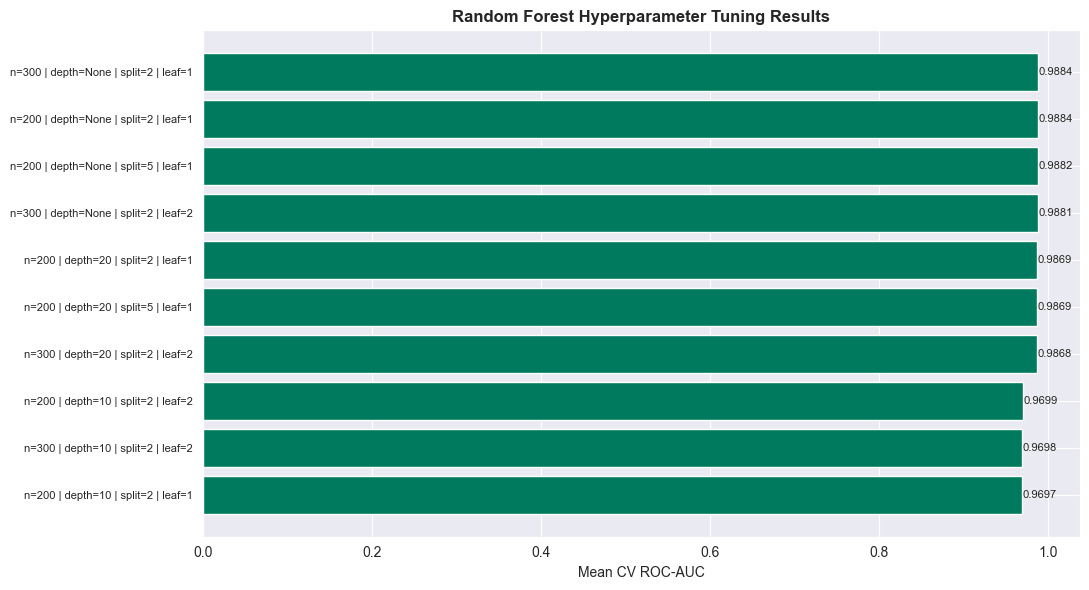

Step 3 slide visuals saved to outputs/.


In [3]:
# Step 3 slide visuals
cv_accuracy_scores = {
    'Logistic Regression': cross_val_score(lr_pipeline, X, y, cv=cv, scoring='accuracy'),
    'Random Forest (Tuned)': cross_val_score(best_model, X, y, cv=cv, scoring='accuracy')
}

cv_accuracy_df = pd.DataFrame(
    {
        'Model': list(cv_accuracy_scores.keys()),
        'Mean_CV_Accuracy': [scores.mean() for scores in cv_accuracy_scores.values()],
        'Std_CV_Accuracy': [scores.std() for scores in cv_accuracy_scores.values()]
    }
).round(4)
print('=== Cross-Validation Accuracy Comparison ===')
print(cv_accuracy_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    cv_accuracy_df['Model'],
    cv_accuracy_df['Mean_CV_Accuracy'],
    yerr=cv_accuracy_df['Std_CV_Accuracy'],
    color=['#4A90D9', '#007A5E'],
    capsize=6
)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('Cross-Validation Accuracy Comparison of Models', fontweight='bold')
for idx, row in cv_accuracy_df.iterrows():
    ax.text(idx, row['Mean_CV_Accuracy'] + 0.005, f"{row['Mean_CV_Accuracy']:.4f}", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/cv_accuracy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
cv_accuracy_df.to_csv('outputs/cv_accuracy_comparison.csv', index=False)

lr_coef = pd.Series(lr_pipeline.named_steps['clf'].coef_[0], index=FEATURES).sort_values(
    key=np.abs,
    ascending=False
)
print('=== Top Logistic Regression Coefficients ===')
print(lr_coef.head(10).round(4).to_string())
lr_coef.rename('coefficient').to_csv('outputs/logistic_regression_coefficients.csv')

top_lr_coef = lr_coef.head(15).sort_values()
lr_colors = ['#E53E3E' if value < 0 else '#007A5E' for value in top_lr_coef]

fig, ax = plt.subplots(figsize=(8, 6))
top_lr_coef.plot(kind='barh', ax=ax, color=lr_colors)
ax.set_title('Logistic Regression Feature Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient (scaled feature space)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('outputs/logistic_regression_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

rf_feature_importance = pd.Series(
    best_model.named_steps['clf'].feature_importances_,
    index=FEATURES
).sort_values(ascending=False)
print('=== Top Random Forest Feature Importance Values ===')
print(rf_feature_importance.head(10).round(4).to_string())
rf_feature_importance.rename('importance').to_csv('outputs/random_forest_feature_importance.csv')

top_rf_importance = rf_feature_importance.head(15).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
top_rf_importance.plot(kind='barh', ax=ax, color='#007A5E')
ax.set_title('Random Forest Feature Importance', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/random_forest_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

grid_results = pd.DataFrame(grid_search.cv_results_).sort_values('mean_test_score', ascending=False).copy()
grid_results['Configuration'] = (
    'n=' + grid_results['param_clf__n_estimators'].astype(str)
    + ' | depth=' + grid_results['param_clf__max_depth'].astype(str)
    + ' | split=' + grid_results['param_clf__min_samples_split'].astype(str)
    + ' | leaf=' + grid_results['param_clf__min_samples_leaf'].astype(str)
)

tuning_export = grid_results[
    [
        'Configuration',
        'mean_test_score',
        'std_test_score',
        'rank_test_score',
        'param_clf__n_estimators',
        'param_clf__max_depth',
        'param_clf__min_samples_split',
        'param_clf__min_samples_leaf'
    ]
].rename(
    columns={
        'mean_test_score': 'Mean_CV_ROC_AUC',
        'std_test_score': 'Std_CV_ROC_AUC',
        'rank_test_score': 'Rank',
        'param_clf__n_estimators': 'n_estimators',
        'param_clf__max_depth': 'max_depth',
        'param_clf__min_samples_split': 'min_samples_split',
        'param_clf__min_samples_leaf': 'min_samples_leaf'
    }
)
tuning_export['Mean_CV_ROC_AUC'] = tuning_export['Mean_CV_ROC_AUC'].round(4)
tuning_export['Std_CV_ROC_AUC'] = tuning_export['Std_CV_ROC_AUC'].round(4)
tuning_export.to_csv('outputs/random_forest_tuning_results.csv', index=False)

print('=== Best Random Forest Tuning Results ===')
print(tuning_export.head(10).to_string(index=False))

top_tuning = tuning_export.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_tuning['Configuration'], top_tuning['Mean_CV_ROC_AUC'], color='#007A5E')
ax.set_xlabel('Mean CV ROC-AUC')
ax.set_title('Random Forest Hyperparameter Tuning Results', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
for idx, score in enumerate(top_tuning['Mean_CV_ROC_AUC']):
    ax.text(score + 0.0005, idx, f"{score:.4f}", va='center', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/random_forest_tuning_results.png', dpi=120, bbox_inches='tight')
plt.show()

print('Step 3 slide visuals saved to outputs/.')


## Summary

| Model | Role | Key Strength |
|---|---|---|
| Logistic Regression | Baseline | Linear, probabilistic, interpretable |
| Random Forest (tuned) | Primary | Non-linear, learns feature interactions |

Step 3 slide visuals saved in `outputs/`:
- `cv_accuracy_comparison.png`
- `logistic_regression_coefficients.png`
- `random_forest_feature_importance.png`
- `random_forest_tuning_results.png`

Both models output an **expiry probability** for the positive class (`expire_before_sold = 1`).

Business-facing sell-through probability is derived later as:

`1 - expiry_probability`
